# Data Collection

> Collect rollouts/episodes from the FindGoal env and save them to disk for later use in training and evaluation.

In [ ]:
#| default_exp data.collect

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from fastcore import *
from fastcore.utils import *

In [2]:
#| hide
import numpy as np
rollouts = [np.load(f'./exp/data/rollouts/rollout_{i}.npz', allow_pickle=True) for i in range(10)]
print(list(rollouts[0].keys()))

['episode_len', 'success', 'success_at', 'seed', 'policy', 'layout', 'goal_obs', 'goal_pos', '0_img', '0_pov', '0_pos', '0_dir', '0_act', '0_rew', '1_img', '1_pov', '1_pos', '1_dir', '1_act', '1_rew']


In [6]:
[rollouts[i]['success'] for i in range(10) if 'success' in rollouts[i].keys()]

[array(False),
 array(False),
 array(False),
 array(False),
 array(False),
 array(False),
 array(False),
 array(False),
 array(False),
 array(False)]

In [7]:
[rollouts[i]['policy'] for i in range(10)]

[array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('random', dtype='<U6'),
 array('waypoint', dtype='<U8'),
 array('waypoint', dtype='<U8'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('waypoint', dtype='<U8')]

In [3]:
rollouts[0]['1_act'].shape

(251,)

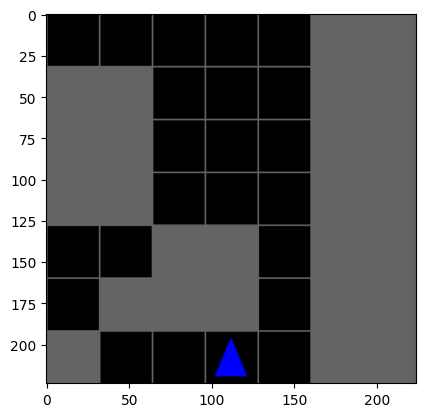

In [18]:
import matplotlib.pyplot as plt
plt.imshow(rollouts[0]['1_pov'][29])
plt.show()

In [1]:
import stable_worldmodel as swm

## FindGoal

In [ ]:
#| hide
from mawm.envs.marl_grid import make_env
from mawm.envs.marl_grid.cfg import config
from mawm.envs.marl_grid.wrappers import GridRecorder
import numpy as np

config.env_cfg.seed = np.random.randint(0, 10000)
config.env_cfg.max_steps = 100

env = make_env(config.env_cfg)


In [ ]:
#| export
def normalize(img):
    return (img - img.min()) / (img.max() - img.min())


In [ ]:
import copy
import os
import numpy as np
from mawm.envs.marl_grid import make_env
from mawm.envs.marl_grid.cfg import config
def collect_one_rollout_numpy(args):
    rollout_idx, seed, seed_steps, data_dir = args

    cfg = copy.deepcopy(config)
    cfg.env_cfg.seed = int(seed)
    cfg.env_cfg.max_steps = seed_steps

    env = make_env(cfg.env_cfg)
    agents = [f"agent_{i}" for i in range(cfg.env_cfg.num_agents)]
    obs = env.reset()
    goal_pos = obs["global"]["goal_pos"]
    goal_obs = np.array([
        env.get_goal(env.agents[i], goal_pos)[0]
        for i in range(config.env_cfg.num_agents)
    ])
    
    layout = env.get_layout(render_kwargs={"tile_size":11})

    agent_data = {
        ag: {k: [] for k in ["obs", "act", "next_obs", "selfpos", "orientation", "sees_goal", "rew", "done"]}
        for ag in agents
    }

    episode_len = 0
    success = False
    success_at = -1

    for t in range(seed_steps):
        current_obs = obs
        actions = {ag: env.action_space.sample() for ag in agents}
        obs, rew, done, info = env.step(actions)
        
        for ag in agents:
            agent_data[ag]["obs"].append(current_obs[ag]["pov"])# list of ndarrays
            agent_data[ag]["act"].append(actions[ag]) # actions are list of int64
            agent_data[ag]["next_obs"].append(obs[ag]["pov"])# list of ndarrays

            agent_data[ag]["selfpos"].append(obs[ag]["selfpos"])# list of ndarrays
            agent_data[ag]["orientation"].append(obs[ag]["orientation"])# list of int64
            agent_data[ag]["sees_goal"].append(info[ag]["sees_goal"])# list of np.int64

            agent_data[ag]["rew"].append(rew[ag])# list of float64
            agent_data[ag]["done"].append(info[ag]["done"])# list of bools

        episode_len += 1
        if done["__all__"]:
            success = all(info[ag]["done"] for ag in agents)
            success_at = t if success else -1
            break

    env.close()
    
    save_path = os.path.join(data_dir, f"rollout_{rollout_idx}.npz")
    os.makedirs(data_dir, exist_ok=True)
    save_dict = {}

    for ag in agents:
        save_dict[f"{ag}_obs"] = np.stack(agent_data[ag]["obs"]).astype(np.uint8)
        save_dict[f"{ag}_act"] = np.asarray(agent_data[ag]["act"])
        save_dict[f"{ag}_next_obs"] = np.stack(agent_data[ag]["next_obs"]).astype(np.uint8)
        save_dict[f"{ag}_done"] = np.asarray(agent_data[ag]["done"])

        save_dict[f"{ag}_rew"] = np.asarray(agent_data[ag]["rew"])
        save_dict[f"{ag}_selfpos"] = np.stack(agent_data[ag]["selfpos"])
        save_dict[f"{ag}_orientation"] = np.asarray(agent_data[ag]["orientation"])
        save_dict[f"{ag}_sees_goal"] = np.asarray(agent_data[ag]["sees_goal"])

    save_dict['goal_pos'] = goal_pos
    save_dict['episode_len'] = episode_len
    save_dict['success'] = success
    save_dict['success_at'] = success_at
    save_dict['seed'] = config.env_cfg.seed
    save_dict['layout'] = layout
    save_dict['goal_obs'] = goal_obs


    np.savez_compressed(save_path, **save_dict)
    print(f"> Saved rollout {rollout_idx} to {save_path}")
    
    return rollout_idx
    


In [ ]:
for i in range(10):
    seed = i % 5
    collect_one_rollout_numpy((i, seed, 3000, './data_test/'))

> Saved rollout 0 to ./data_test/rollout_0.npz
> Saved rollout 1 to ./data_test/rollout_1.npz
> Saved rollout 2 to ./data_test/rollout_2.npz
> Saved rollout 3 to ./data_test/rollout_3.npz
> Saved rollout 4 to ./data_test/rollout_4.npz
> Saved rollout 5 to ./data_test/rollout_5.npz
> Saved rollout 6 to ./data_test/rollout_6.npz
> Saved rollout 7 to ./data_test/rollout_7.npz
> Saved rollout 8 to ./data_test/rollout_8.npz
> Saved rollout 9 to ./data_test/rollout_9.npz


In [ ]:
#| hide
import numpy as np
rollout = np.load(f'./data_test/rollout_0.npz', allow_pickle=True)
print(list(rollout.keys()))
rollout['agent_0_obs'].shape, rollout['agent_0_next_obs'].shape, rollout['agent_0_act'].shape

['agent_0_obs', 'agent_0_act', 'agent_0_next_obs', 'agent_0_done', 'agent_0_rew', 'agent_0_selfpos', 'agent_0_orientation', 'agent_0_sees_goal', 'agent_1_obs', 'agent_1_act', 'agent_1_next_obs', 'agent_1_done', 'agent_1_rew', 'agent_1_selfpos', 'agent_1_orientation', 'agent_1_sees_goal', 'goal_pos', 'episode_len', 'success', 'success_at', 'seed', 'layout', 'goal_obs']


((1000, 42, 42, 3), (1000, 42, 42, 3), (1000,))

In [ ]:
rollout['episode_len'].item()

1000

In [ ]:
rollout['agent_0_obs'][0].dtype

dtype('uint8')

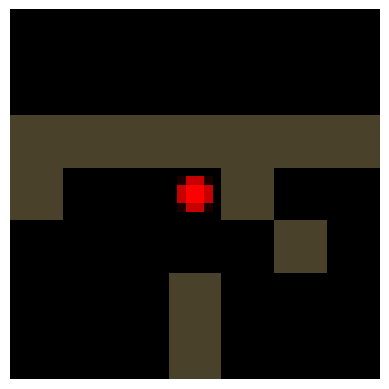

In [ ]:
#| hide
import matplotlib.pyplot as plt
img = rollout['agent_0_obs'][20]
# normalize = lambda img: (img - img.min()) / (img.max() - img.min())
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
rollout['agent_0_obs'].shape

(100, 42, 42, 3)

['Done', 'Right', 'Up', 'Done', 'Up']


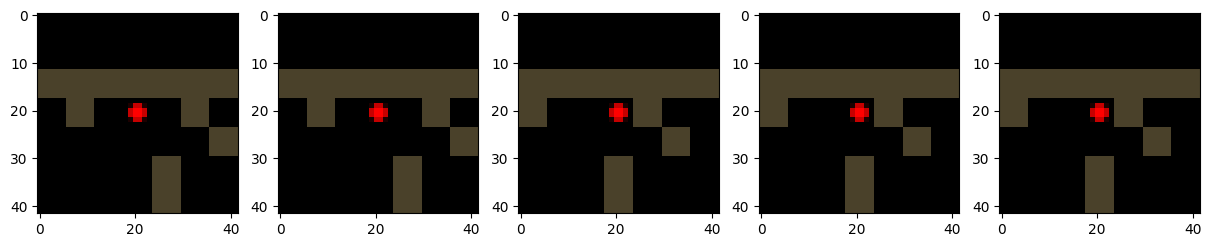

In [ ]:
#| hide
action_mapping = {
    0: "Right",
    1: "Down",
    2: "Left",
    3: "Up",
    4: "Done",
    }
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 5, figsize=(15,6))
idx = 0
ds = rollout
for i in range(15, 20):
    obs = ds['agent_0_obs'][i]
    next_obs = ds['agent_0_next_obs'][i]
    ax = axs[i - 15]
    ax.imshow(obs)
    # ax.set_title(f"Step {ds['transition_idx'][i]}, R{ds['rollout_idx'][i]}")
print([action_mapping[a] for a in ds['agent_0_act'][15:20]])
plt.savefig('example_rollout_steps.png')
plt.show()

In [ ]:
#| hide
import numpy as np
list_itms = [np.random.rand(42, 42, 3) for _ in range(5)]
np.stack(list_itms).shape

(5, 42, 42, 3)

In [ ]:
#| export
import numpy as np
import os
from mawm.envs.marl_grid import make_env
from mawm.envs.marl_grid.cfg import config

def generate_data_marl_grid_np(
    rollouts=3,
    seed_steps=4000,
    data_dir='../marl_grid_data',
    save_metadata=True,      # NEW: save environment metadata
    env_name="marl_grid"
):
    """Generate and save full rollouts from a MarlGrid environment."""
    
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    
    def create_env():
        config.env_cfg.seed = np.random.randint(0, 5) # use only small set of envs for training.
        config.env_cfg.max_steps = seed_steps
        env = make_env(config.env_cfg)
        agents = [f'agent_{i}' for i in range(config.env_cfg.num_agents)]
        return env, agents
    
    # Save config metadata once
    if save_metadata:
        meta_path = os.path.join(data_dir, "metadata.npz")
        np.savez_compressed(meta_path, 
                          grid_size=config.env_cfg.grid_size,
                          num_agents=config.env_cfg.num_agents,
                          max_steps=seed_steps,
                          view_size=config.env_cfg.view_size)
    
    for rollout_idx in range(rollouts):
        print(f"\nStarting rollout {rollout_idx}...")
        env, agents = create_env()
        
        # Fresh buffers for each rollout
        agent_data = {
            ag: {
                "obs":  [], 
                "selfpos": [], 
                "orientation": [],
                "sees_goal": [],
                "rew":  [], 
                "act":  [], 
                "done": [],  # Per-agent done status
            } for ag in agents
        }
        
        
        obs = env.reset()
        success = False
        success_at = -1
        goal_pos = obs['global']['goal_pos']
        # import ipdb; ipdb.set_trace()
        goal_obs = np.array([env.get_goal(env.agents[i], goal_pos)[0] for i in range(config.env_cfg.num_agents)])
        
        # Store initial observations
        for idx, ag in enumerate(agents):
            agent_data[ag]["obs"].append(obs[ag]['pov'])
            agent_data[ag]["selfpos"].append(obs[ag]['selfpos'])
            agent_data[ag]["orientation"].append(obs[ag]['orientation'])
            agent_data[ag]["sees_goal"].append(obs["global"]['sees_goal'][idx])
            agent_data[ag]["done"].append(False)  # Initial done status is False
        
        
        
        episode_len = 0
        
        for t in range(seed_steps):
            actions = {ag: env.action_space.sample() for ag in agents}
            obs, rew, done, info = env.step(actions)
            
            for ag in agents:
                agent_data[ag]["obs"].append(obs[ag]['pov'])
                agent_data[ag]["selfpos"].append(obs[ag]['selfpos'])
                agent_data[ag]["orientation"].append(obs[ag]['orientation'])
                agent_data[ag]["sees_goal"].append(info[ag]['sees_goal'])

                agent_data[ag]["rew"].append(rew[ag])
                agent_data[ag]["act"].append(actions[ag])
                agent_data[ag]["done"].append(info[ag]['done'])

                
            
            episode_len += 1
            
            if done['__all__']:
                success = True if all(info[ag]['done'] for ag in agents) else False
                success_at = t if success else -1
                print(f"> Rollout {rollout_idx} ended at step {t} (goal reached or timeout)")
                break
        
        # Save rollout
        save_path = os.path.join(data_dir, f"rollout_{rollout_idx}.npz")
        save_dict = {
            "episode_len": episode_len,
            "rng_state": env.np_random.bit_generator.state['state']['state'],  # Save RNG state for reproducibility
            "seed": config.env_cfg.seed,
            "goal_pos": goal_pos,
            "goal_obs": goal_obs,
            "success": success,
            "success_at": success_at
        }
        final_dict = {
            "global": np.array([save_dict]),
        }

        for agent in agents:
            final_dict[agent] = {
                "obs": np.stack(agent_data[agent]["obs"]),
                "selfpos": np.stack(agent_data[agent]["selfpos"]),
                "orientation": np.stack(agent_data[agent]["orientation"]),
                "sees_goal": np.stack(agent_data[agent]["sees_goal"]),

                "act": np.stack(agent_data[agent]["act"]),
                "rew": np.stack(agent_data[agent]["rew"]),
                "done": np.stack(agent_data[agent]["done"]),
            }
            print(np.stack(agent_data[agent]["obs"]).shape)
        
        
            
        np.savez_compressed(save_path, **final_dict)
        print(f"> Saved rollout {rollout_idx} ({episode_len} steps) to {save_path}")
        
        env.close()
    
    print(f"\nData generation complete! {rollouts} rollouts saved to {data_dir}")

In [ ]:
#| export
import numpy as np
import os
import h5py
from mawm.envs.marl_grid import make_env
from mawm.envs.marl_grid.cfg import config


def generate_data_marl_grid_h52(
    rollouts=3,
    seed_steps=4000,
    data_dir="../marl_grid_data",
    env_name="marl_grid"
):

    os.makedirs(data_dir, exist_ok=True)

    def create_env():
        config.env_cfg.seed = np.random.randint(0, 5)
        config.env_cfg.max_steps = seed_steps
        env = make_env(config.env_cfg)
        agents = [f"agent_{i}" for i in range(config.env_cfg.num_agents)]
        return env, agents

    # ---- Save metadata ONCE ----
    meta_path = os.path.join(data_dir, "metadata.h5")
    if not os.path.exists(meta_path):
        with h5py.File(meta_path, "w") as f:
            f.attrs["grid_size"] = config.env_cfg.grid_size
            f.attrs["num_agents"] = config.env_cfg.num_agents
            f.attrs["max_steps"] = seed_steps
            f.attrs["view_size"] = config.env_cfg.view_size

    for rollout_idx in range(rollouts):
        print(f"\nStarting rollout {rollout_idx}...")

        env, agents = create_env()
        obs = env.reset()

        goal_pos = obs["global"]["goal_pos"]
        goal_obs = np.array(
            [env.get_goal(env.agents[i], goal_pos)[0]
             for i in range(config.env_cfg.num_agents)]
        )

        agent_data = {
            ag: {k: [] for k in
                 ["obs", "selfpos", "orientation", "sees_goal",
                  "act", "rew", "done"]}
            for ag in agents
        }

        # ---- initial observation ----
        for i, ag in enumerate(agents):
            agent_data[ag]["obs"].append(obs[ag]["pov"])
            agent_data[ag]["selfpos"].append(obs[ag]["selfpos"])
            agent_data[ag]["orientation"].append(obs[ag]["orientation"])
            agent_data[ag]["sees_goal"].append(obs["global"]["sees_goal"][i])
            agent_data[ag]["done"].append(False)

        episode_len = 0
        success = False
        success_at = -1

        for t in range(seed_steps):
            actions = {ag: env.action_space.sample() for ag in agents}
            obs, rew, done, info = env.step(actions)

            for ag in agents:
                agent_data[ag]["obs"].append(obs[ag]["pov"])
                agent_data[ag]["selfpos"].append(obs[ag]["selfpos"])
                agent_data[ag]["orientation"].append(obs[ag]["orientation"])
                agent_data[ag]["sees_goal"].append(info[ag]["sees_goal"])
                agent_data[ag]["act"].append(actions[ag])
                agent_data[ag]["rew"].append(rew[ag])
                agent_data[ag]["done"].append(info[ag]["done"])

            episode_len += 1
            if done["__all__"]:
                success = all(info[ag]["done"] for ag in agents)
                success_at = t if success else -1
                print(f"> Rollout {rollout_idx} ended at step {t} (goal reached or timeout), success: {success}")
                break

        env.close()

        # ---- WRITE HDF5 FILE ----
        save_path = os.path.join(data_dir, f"rollout_{rollout_idx}.h5")

        with h5py.File(save_path, "w") as f:

            # ---- global group ----
            g = f.create_group("global")
            g.create_dataset("episode_len", data=episode_len)
            g.create_dataset("goal_pos", data=goal_pos)
            g.create_dataset("goal_obs", data=goal_obs)
            g.create_dataset("success", data=success)
            g.create_dataset("success_at", data=success_at)
            g.attrs["seed"] = config.env_cfg.seed

            # ---- agents ----
            for ag in agents:
                ag_g = f.create_group(ag)

                for key, seq in agent_data[ag].items():
                    arr = np.stack(seq)
                    ag_g.create_dataset(
                        key,
                        data=arr,
                        compression="gzip",
                        compression_opts=4,
                        chunks=True
                    )

        print(f"> Saved rollout {rollout_idx} ({episode_len} steps) → {save_path}")

    print(f"\nData generation complete: {rollouts} rollouts saved.")


In [ ]:
#| export
import os
import numpy as np
import h5py
from mawm.envs.marl_grid import make_env
from mawm.envs.marl_grid.cfg import config

def collect_one_rollout_h5(args):
    rollout_idx, seed_steps, data_dir = args  

    config.env_cfg.seed = np.random.randint(0, 5)
    config.env_cfg.max_steps = seed_steps

    env = make_env(config.env_cfg)
    agents = [f"agent_{i}" for i in range(config.env_cfg.num_agents)]

    obs = env.reset()
    goal_pos = obs["global"]["goal_pos"]
    goal_obs = np.array(
            [env.get_goal(env.agents[i], goal_pos)[0]
             for i in range(config.env_cfg.num_agents)]
            )
    layout = env.get_layout(render_kwargs={"tile_size":11})

    agent_data = {
        ag: {k: [] for k in
             ["obs", "selfpos", "orientation", "sees_goal",
              "act", "rew", "done"]}
        for ag in agents
    }

    for i, ag in enumerate(agents):
        agent_data[ag]["obs"].append(obs[ag]["pov"])
        agent_data[ag]["selfpos"].append(obs[ag]["selfpos"])
        agent_data[ag]["orientation"].append(obs[ag]["orientation"])
        agent_data[ag]["sees_goal"].append(obs["global"]["sees_goal"][i])
        agent_data[ag]["done"].append(False)

    episode_len = 0
    success = False
    success_at = -1

    for t in range(seed_steps):
        actions = {ag: env.action_space.sample() for ag in agents}
        obs, rew, done, info = env.step(actions)

        for ag in agents:
            agent_data[ag]["obs"].append(obs[ag]["pov"])
            agent_data[ag]["selfpos"].append(obs[ag]["selfpos"])
            agent_data[ag]["orientation"].append(obs[ag]["orientation"])
            agent_data[ag]["sees_goal"].append(info[ag]["sees_goal"])
            agent_data[ag]["act"].append(actions[ag])
            agent_data[ag]["rew"].append(rew[ag])
            agent_data[ag]["done"].append(info[ag]["done"])

        episode_len += 1
        if done["__all__"]:
            success = all(info[ag]["done"] for ag in agents)
            success_at = t if success else -1
            break

    env.close()

    roolout_dir = os.path.join(data_dir, f"rollout_{rollout_idx}")
    os.makedirs(roolout_dir, exist_ok=True)
    save_path = os.path.join(roolout_dir, f"rollout_{rollout_idx}.h5")
    metadata_path = os.path.join(roolout_dir, "metadata.h5")

    with h5py.File(metadata_path, "w") as f:
        g = f.create_group("global")
        g.create_dataset("layout", data=layout)
        g.create_dataset("goal_pos", data=goal_pos)
        g.create_dataset("goal_obs", data=goal_obs)

        g.attrs["episode_len"] = episode_len
        g.attrs["success"] = success
        g.attrs["success_at"] = success_at
        g.attrs["seed"] = config.env_cfg.seed
        g.attrs["rng_state"] = str(env.np_random.bit_generator.state['state']['state'])
        
    f.close()
    with h5py.File(save_path, "w") as f:
        for ag in agents:
            ag_g = f.create_group(ag)
            for k, seq in agent_data[ag].items():
                ag_g.create_dataset(
                    k,
                    data=np.stack(seq),
                    compression="gzip",
                    chunks=True
                )
    f.close()
    
    return rollout_idx


/home/ahmed/Ahmed-home/1- Projects/Research/Journal 2/Code/mawm/mawm/envs/marl_grid/__init__.py:1: SyntaxWarning: invalid escape sequence '\_'
  """Acts as module \__init__ for MarlGrid envs creation"""
/home/ahmed/Ahmed-home/1- Projects/Research/Journal 2/Code/mawm/mawm/envs/marl_grid/wrappers.py:1: SyntaxWarning: invalid escape sequence '\_'
  """Acts as module \__init__ for MarlGrid envs creation  -->"""


In [ ]:
#| export
import numpy as np
from pathlib import Path

def combine_npz_files(meta_files, output_file="meta_data_merged.npz"):
    master_dict = {}

    for i, file_path in enumerate(meta_files):
        with np.load(file_path, allow_pickle=True) as data:
            for key in data.files:
                new_key = f"rollout_{i}_{key}"
                master_dict[new_key] = data[key]

    np.savez_compressed(output_file, **master_dict)